<a href="https://colab.research.google.com/github/nicollysoarez/projeto-MPG/blob/Meus-Projetos/Previsao_de_Consumo_de_Combustivel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

explorando os dados 1º:


In [2]:
import pandas as pd


df = pd.read_csv("mpg_desafio_alunos (1).csv")


df.info()

print("\nValores nulos por coluna:")
print(df.isnull().sum())

# matriz de correlação c/ mpg
print("\nCorrelação com mpg:")
print(df.corr(numeric_only=True)["mpg"].sort_values())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339 entries, 0 to 338
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           339 non-null    float64
 1   cylinders     339 non-null    int64  
 2   displacement  339 non-null    float64
 3   horsepower    333 non-null    float64
 4   weight        339 non-null    int64  
 5   acceleration  339 non-null    float64
 6   model_year    339 non-null    int64  
 7   origin        339 non-null    object 
 8   name          339 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 24.0+ KB

Valores nulos por coluna:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

Correlação com mpg:
weight         -0.828402
displacement   -0.801106
horsepower     -0.779942
cylinders      -0.766457
acceleration    0.430286
model_year  

escolhendo a feature 2º:

In [6]:
# 'weight' = maior correlação com 'mpg' (~ -0.83)
X = df[["weight"]]
y = df["mpg"]

tratando valores nulos 3º:

In [7]:
# coluna 'weight' = sem valores nulos


print("Quantidade de nulos na feature X:", X.isnull().sum().values[0])

Quantidade de nulos na feature X: 0


separando treino e teste 4º:

In [8]:
from sklearn.model_selection import train_test_split

# seed para reprodutibilidade
SEED = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f"Tamanho do treino: {len(X_train)} | Tamanho do teste: {len(X_test)}")

Tamanho do treino: 271 | Tamanho do teste: 68


treinando regressão linear 5º:


In [9]:
from sklearn.linear_model import LinearRegression

modelo_linear = LinearRegression()
modelo_linear.fit(X_train, y_train)

print(f"Coeficiente (inclinacao): {modelo_linear.coef_[0]:.4f}")
print(f"Intercepto: {modelo_linear.intercept_:.4f}")

Coeficiente (inclinacao): -0.0076
Intercepto: 45.8616


avaliando (MAE, MSE, R²) 6:

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


y_pred_lin = modelo_linear.predict(X_test)

mae_lin = mean_absolute_error(y_test, y_pred_lin)
mse_lin = mean_squared_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print("--- Desempenho no Teste (Regressão Linear Simples) ---")
print(f"MAE: {mae_lin:.3f}")
print(f"MSE: {mse_lin:.3f}")
print(f"R²:  {r2_lin:.3f}")

--- Desempenho no Teste (Regressão Linear Simples) ---
MAE: 3.035
MSE: 15.892
R²:  0.705


melhorando (polinomial) 7º:

In [11]:
from sklearn.preprocessing import PolynomialFeatures

# polinomial 2º grau
poly2 = PolynomialFeatures(degree=2)
X_train_p2 = poly2.fit_transform(X_train)
X_test_p2 = poly2.transform(X_test)

modelo_p2 = LinearRegression()
modelo_p2.fit(X_train_p2, y_train)

r2_p2_train = r2_score(y_train, modelo_p2.predict(X_train_p2))
r2_p2_test = r2_score(y_test, modelo_p2.predict(X_test_p2))

# polinomial 3º grau
poly3 = PolynomialFeatures(degree=3)
X_train_p3 = poly3.fit_transform(X_train)
X_test_p3 = poly3.transform(X_test)

modelo_p3 = LinearRegression()
modelo_p3.fit(X_train_p3, y_train)

r2_p3_train = r2_score(y_train, modelo_p3.predict(X_train_p3))
r2_p3_test = r2_score(y_test, modelo_p3.predict(X_test_p3))

print(f"Grau 2 -> R² Treino: {r2_p2_train:.3f} | R² Teste: {r2_p2_test:.3f}")
print(f"Grau 3 -> R² Treino: {r2_p3_train:.3f} | R² Teste: {r2_p3_test:.3f}")

Grau 2 -> R² Treino: 0.708 | R² Teste: 0.701
Grau 3 -> R² Treino: 0.708 | R² Teste: 0.701


gráfico matplotlib:

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


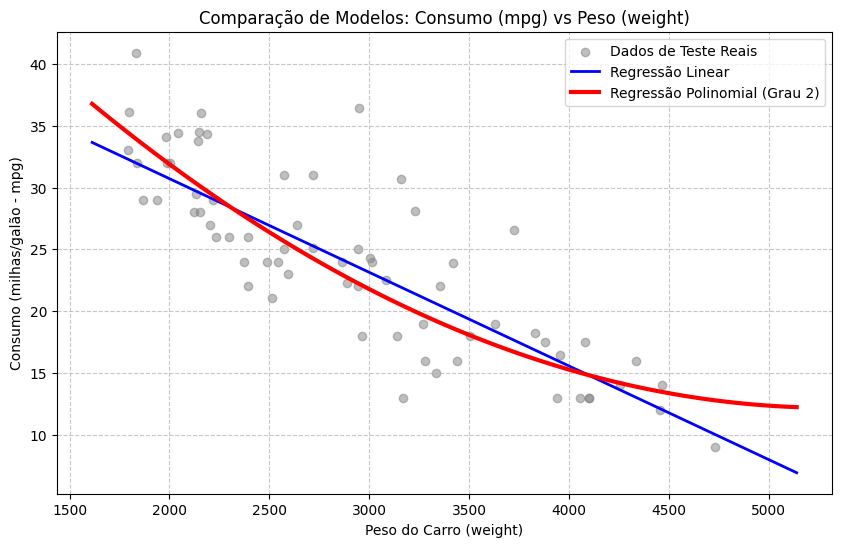

In [12]:
import matplotlib.pyplot as plt
import numpy as np

x_range = np.linspace(df["weight"].min(), df["weight"].max(), 100).reshape(-1, 1)

# intervalo criado
y_pred_linear_range = modelo_linear.predict(x_range)
y_pred_poly2_range = modelo_p2.predict(poly2.transform(x_range))


plt.figure(figsize=(10, 6))

# dados reais de teste (Scatter)
plt.scatter(X_test, y_test, color='gray', alpha=0.5, label='Dados de Teste Reais')

# reta da Regressão Linear Simples
plt.plot(x_range, y_pred_linear_range, color='blue', linewidth=2, label='Regressão Linear')

# curva da Regressão Polinomial Grau 2
plt.plot(x_range, y_pred_poly2_range, color='red', linewidth=3, label='Regressão Polinomial (Grau 2)')


plt.title('Comparação de Modelos: Consumo (mpg) vs Peso (weight)')
plt.xlabel('Peso do Carro (weight)')
plt.ylabel('Consumo (milhas/galão - mpg)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)


plt.show()